# 📊 Projeto Analytics Educação Básica (INEP)
## Análise Exploratória de Dados (EDA): Infraestrutura, Inclusão Digital e Perfil de Oferta em Minas Gerais (2019–2025)

---

**Autor:** Juliano França da Mata  
**Curso:** Bacharelado em Ciência de Dados e Inteligência Artificial  
**Data:** Julho / 2026  
**Banco de Dados Fonte:** Microsoft SQL Server (`Educacao_Analytics`)  

---

### 📝 Descrição Geral e Objetivos do Estudo

Este *Jupyter Notebook* realiza a **Análise Exploratória e Diagnóstica dos Microdados do Censo Escolar da Educação Básica (INEP)** no estado de **Minas Gerais**, cobrindo a série histórica de **2019 a 2025**.

A análise mapeia a evolução dos indicadores de infraestrutura tecnológica (acesso à internet, banda larga e laboratórios de informática) nas redes públicas de ensino (**Estadual e Municipal**), investigando gargalos de conectividade e o perfil da oferta escolar para fornecer subsídios quantitativos à gestão pública.

#### 🎯 Objetivos Específicos:
1. **Conexão e Extração Otimizada:** Conectar o ambiente Python ao SQL Server local via `SQLAlchemy` e `pyodbc`, consumindo diretamente as visões analíticas.
2. **Evolução Temporal (2019–2025):** Quantificar a expansão da conectividade digital nas escolas públicas mineiras ao longo da série histórica.
3. **Mapeamento de Disparidades Regionais:** Identificar municípios com índices críticos de exclusão digital e privação de infraestrutura.
4. **Perfil da População Atendida:** Investigar a distribuição das escolas e do contingente de matrículas na Educação Básica Regular (Infantil, Fundamental e Médio).
5. **Análise de Variáveis Estruturais:** Avaliar a coexistência de recursos tecnológicos e bibliotecas nos estabelecimentos de ensino.
6. **Exportação de Artefatos:** Gerar e exportar automaticamente os gráficos de alta resolução (300 DPI) para o diretório de documentação `/Imagens`.

---

## 📖 Dicionário de Dados e Metadados do Censo Escolar

A tabela abaixo descreve as variáveis fundamentais extraídas dos microdados do Censo Escolar (INEP) e consolidadas no pipeline analítico:

| Nome da Variável | Tipo de Dado | Descrição / Regra de Negócio |
| :--- | :--- | :--- |
| `Ano_Censo` | `int` | Ano de referência da coleta dos dados do Censo Escolar (2019–2025). |
| `Codigo_Escola` / `CO_ENTIDADE` | `int` | Código identificador único da escola no cadastro do INEP. |
| `Municipio` / `NO_MUNICIPIO` | `str` | Nome do município mineiro onde a unidade está localizada. |
| `Total_Matriculas` / `QT_MAT_BAS` | `int` | Volume total de alunos matriculados na **Educação Básica Regular** (Infantil, Fundamental e Médio). |
| `Tem_Internet` / `IN_INTERNET` | `binary` | Indicador de conectividade (`1` = Possui acesso à internet; `0` = Ausente). |
| `Tem_Banda_Larga` / `IN_BANDA_LARGA` | `binary` | Indicador de internet de alta velocidade (`1` = Possui; `0` = Ausente/Nulo). |
| `Tem_Lab_Info` / `IN_LABORATORIO_INFORMATICA` | `binary` | Presença de laboratório de informática estruturado (`1` = Possui; `0` = Ausente). |
| `Score_Vulnerabilidade` | `float` | Pontuação contínua gerada pelo modelo preditivo (0 a 100) indicando o grau de risco. |
| `Status_Alerta` | `str` | Categoria de risco para gestão pública (🟢 Baixo Risco, 🟡 Médio Risco, 🔴 Risco Crítico). |

---

### 🎓 Nota Metodológica: Escopo da População Estudantil

> **Abrangência das Matrículas (`Total_Matriculas` / `QT_MAT_BAS`):**
> O indicador volumétrico utilizado engloba a totalidade dos estudantes matriculados na **Educação Básica Regular** (Educação Infantil, Ensino Fundamental e Ensino Médio) das redes públicas de ensino de Minas Gerais.
> 
> * **Justificativa de Modelagem:** O agrupamento na variável reflete a capacidade física e a carga de atendimento global do estabelecimento escolar.
> * **Foco Social de Impacto:** O modelo de Alerta Precoce direciona sua sensibilidade preditiva prioritariamente ao ecossistema dos **Anos Finais do Ensino Fundamental** e do **Ensino Médio**, etapas que concentram historicamente os maiores índices de evasão e vulnerabilidade no estado.


---

## 1️⃣ Configuração do Ambiente e Estrutura Executiva

Esta etapa inicial estabelece as dependências técnicas, o padrão de estilo para visualização gráfica e a infraestrutura de diretórios do projeto:

* **Módulos Fundamentais:** Carregamento das bibliotecas de manipulação de dados (`pandas`, `numpy`), visualização (`matplotlib`, `seaborn`) e conexão com o banco de dados SQL Server (`sqlalchemy`).
* **Padronização Estética:** Definição da paleta e estilo dos gráficos para manter consistência visual acadêmica e executiva.
* **Portabilidade do Pipeline:** Mapeamento dinâmico e criação automatizada das pastas locais (`Imagens` e `outputs`) para garantir que o script rode em qualquer ambiente sem quebra de caminhos.

In [1]:
# ==============================================================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS E CONFIGURAÇÕES DO AMBIENTE
# ==============================================================================

import os
from urllib.parse import quote_plus

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine

# 1.1 Configuração do estilo visual e alta resolução (Garante Objetivo 6: 300 DPI)
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 0.8
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300

# 1.2 Estrutura Centralizada de Diretórios (Garante a portabilidade do projeto)
PASTA_IMAGENS = os.path.join("..", "Imagens")
PASTA_OUTPUTS = os.path.join("..", "Dados_Educacao", "outputs")

os.makedirs(PASTA_IMAGENS, exist_ok=True)
os.makedirs(PASTA_OUTPUTS, exist_ok=True)

print(
    f"✅ Ambiente configurado com sucesso! Biblioteca Pandas {pd.__version__} ativa.\n"
    f"📸 Diretório de exportação de imagens: '{PASTA_IMAGENS}'\n"
    f"📁 Diretório de outputs estruturados: '{PASTA_OUTPUTS}'"
)

✅ Ambiente configurado com sucesso! Biblioteca Pandas 3.0.3 ativa.
📸 Diretório de exportação de imagens: '..\Imagens'
📁 Diretório de outputs estruturados: '..\Dados_Educacao\outputs'


---

## 2️⃣ Conexão com o Banco de Dados e Carga da Camada Analítica

Nesta etapa, estabelecemos a conexão entre o ambiente de execução Python e a instância local do **Microsoft SQL Server** (`MATA-ACER\SQLEXPRESS`), utilizando a biblioteca `SQLAlchemy` combinada com o driver `PyODBC`.

Para garantir o isolamento da camada de banco de dados e a máxima performance na leitura, os dados são extraídos diretamente da view analítica `dbo.vw_fato_educacao_mg`. A consulta T-SQL agrega a série histórica de **2019 a 2025** do estado de **Minas Gerais**, agrupando os indicadores por **Ano do Censo** e **Rede de Ensino** (Estadual e Municipal).

#### 🛠️ Métricas Extraídas e Consolidadas:
* **Volume Populacional e de Oferta:** Contagem total de estabelecimentos (`Total_Escolas`) e volume de alunos (`Total_Matriculas`).
* **Indicadores Absolutos de Infraestrutura:** Quantitativo de escolas com Internet, Banda Larga, Laboratório de Informática e Biblioteca.
* **Indicadores Relativos (%):** Taxas percentuais de cobertura tecnológica calculadas diretamente no motor SQL para análise comparativa temporal.

In [2]:
# ==============================================================================
# 2. CONEXÃO COM O SQL SERVER, CARGA E PADRONIZAÇÃO DO CONTRATO DE DADOS
# ==============================================================================

# 2.1 Parâmetros de Instância e Banco de Dados
SERVIDOR = r"MATA-ACER\SQLEXPRESS"
BANCO = "Educacao_Analytics"

# String de Conexão ODBC Codificada via urllib
params_conexao = quote_plus(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={SERVIDOR};"
    f"DATABASE={BANCO};"
    f"Trusted_Connection=yes;"
    f"TrustServerCertificate=yes;"
)

# Instanciação do Motor SQLAlchemy
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params_conexao}")

# 2.2 Query T-SQL Agregada por Ano e Rede de Ensino (vw_fato_educacao_mg)
query_mg_infra = """
SELECT 
    Ano AS Ano_Censo,
    Rede_Ensino,
    COUNT(*) AS Total_Escolas,
    SUM(CAST(Total_Matriculas AS BIGINT)) AS Total_Matriculas,
    SUM(CAST(Possui_Internet AS INT)) AS Escolas_com_Internet,
    SUM(CAST(Possui_Banda_Larga AS INT)) AS Escolas_com_Banda_Larga,
    SUM(CAST(Possui_Lab_Informatica AS INT)) AS Laboratorio_Informatica,
    SUM(CAST(Possui_Biblioteca AS INT)) AS Biblioteca_Espaco_Leitura,
    ROUND(SUM(CAST(Possui_Internet AS FLOAT)) * 100.0 / COUNT(*), 2) AS Perc_Escolas_Internet,
    ROUND(SUM(CAST(Possui_Banda_Larga AS FLOAT)) * 100.0 / COUNT(*), 2) AS Perc_Escolas_Banda_Larga
FROM dbo.vw_fato_educacao_mg
GROUP BY Ano, Rede_Ensino
ORDER BY Ano, Rede_Ensino;
"""

# Leitura e armazenamento no DataFrame Master
df_mg_infra = pd.read_sql(query_mg_infra, engine)

# 2.3 Garantia de Integridade dos Tipos Inteiros
colunas_inteiras = [
    "Ano_Censo",
    "Total_Escolas",
    "Total_Matriculas",
    "Escolas_com_Internet",
    "Escolas_com_Banda_Larga",
    "Laboratorio_Informatica",
    "Biblioteca_Espaco_Leitura",
]
df_mg_infra[colunas_inteiras] = df_mg_infra[colunas_inteiras].astype("Int64")

print("✅ DataFrame Master carregado e padronizado com sucesso (Série Histórica Completa):")
display(df_mg_infra)

✅ DataFrame Master carregado e padronizado com sucesso (Série Histórica Completa):


,Ano_Censo,Rede_Ensino,Total_Escolas,Total_Matriculas,Escolas_com_Internet,Escolas_com_Banda_Larga,Laboratorio_Informatica,Biblioteca_Espaco_Leitura,Perc_Escolas_Internet,Perc_Escolas_Banda_Larga
0,2019,Estadual,4322,1870861,3579,3563,3191,3427,82.81,82.44
1,2019,Municipal,13807,1748301,6533,5826,2467,3567,47.32,42.20
2,2020,Estadual,4324,1854397,3552,3536,3186,3412,82.15,81.78
3,2020,Municipal,13477,1741793,6701,5899,2446,3594,49.72,43.77
4,2021,Estadual,4319,1744621,3539,3519,3213,3415,81.94,81.48
5,2021,Municipal,13363,1749814,6954,6071,2362,3603,52.04,45.43
6,2022,Estadual,4316,1720549,3484,3466,3164,3353,80.72,80.31
7,2022,Municipal,13471,1798852,7327,6437,2224,3665,54.39,47.78
8,2023,Estadual,4294,1629756,3452,3428,3175,3299,80.39,79.83
9,2023,Municipal,13441,1817606,7696,6767,2140,3682,57.26,50.35


---

## 3️⃣ Diagnóstico Territorial: Mapeamento de Municípios Críticos em Minas Gerais

Nesta etapa, isolamos o ano mais recente da série histórica disponível para mapear os municípios mineiros que concentram o maior volume absoluto de escolas públicas sem conectividade básica e sem laboratórios de informática.

#### 🎯 Objetivos do Diagnóstico Local:
* **Matriz de Priorização:** Identificar territorialmente onde o déficit tecnológico é mais severo no estado.
* **Volume Populacional Afetado:** Mensurar o quantitativo de matrículas públicas diretamente submetidas ao isolamento digital em cada localidade.
* **Filtro de Redes Públicas:** Restringir a análise às esferas **Estadual e Municipal** (`TP_DEPENDENCIA IN (2, 3)`), focando na atuação direta da gestão pública.

In [3]:
# ==============================================================================
# 3. DIAGNÓSTICO DE MUNICÍPIOS CRÍTICOS EM MINAS GERAIS (ANO RECENTE)
# ==============================================================================

# 3.1 Query T-SQL para identificação dos 50 municípios com maior déficit
query_municipios_criticos = """
SELECT TOP 50
    m.NO_MUNICIPIO AS Municipio,
    SUM(CAST(ISNULL(f.QT_MAT_BAS, 0) AS BIGINT)) AS Total_Matriculas_Publicas,
    COUNT(f.CO_ENTIDADE) AS Total_Escolas,
    SUM(CASE WHEN ISNULL(f.IN_INTERNET, 0) = 0 THEN 1 ELSE 0 END) AS Escolas_Sem_Internet,
    SUM(CASE WHEN ISNULL(f.IN_LABORATORIO_INFORMATICA, 0) = 0 THEN 1 ELSE 0 END) AS Escolas_Sem_Lab_Info
FROM dbo.fato_censo_escolar f
INNER JOIN (
    SELECT DISTINCT CO_MUNICIPIO, NO_MUNICIPIO
    FROM dbo.dim_localizacao
    WHERE SG_UF = 'MG'
) m ON f.CO_MUNICIPIO = m.CO_MUNICIPIO
WHERE f.TP_DEPENDENCIA IN (2, 3) -- Redes Estadual e Municipal
  AND f.NU_ANO_CENSO = (SELECT MAX(NU_ANO_CENSO) FROM dbo.fato_censo_escolar)
GROUP BY m.NO_MUNICIPIO
HAVING SUM(CASE WHEN ISNULL(f.IN_INTERNET, 0) = 0 THEN 1 ELSE 0 END) > 0
ORDER BY Escolas_Sem_Internet DESC, Total_Matriculas_Publicas DESC;
"""

# Leitura dos dados no Pandas
df_criticos = pd.read_sql(query_municipios_criticos, engine)

# 3.2 Garantia de Tipos Inteiros
colunas_num_criticos = [
    "Total_Matriculas_Publicas",
    "Total_Escolas",
    "Escolas_Sem_Internet",
    "Escolas_Sem_Lab_Info",
]
df_criticos[colunas_num_criticos] = df_criticos[colunas_num_criticos].astype("Int64")

# 3.3 Captura dinâmica do ano ativo para o cabeçalho do relatório
ano_atual_criticos = df_mg_infra["Ano_Censo"].max()

print(f"📌 TABELA 01: TOP 50 MUNICÍPIOS MINEIROS COM MAIOR DÉFISIT TECNOLÓGICO ({ano_atual_criticos})")


# 3.4 Função de Formatação (Padrão PT-BR)
def formatar_milhar_ptbr(valor):
    if pd.isna(valor):
        return "-"
    return f"{valor:,.0f}".replace(",", ".")


# Exibição estilizada com gradiente e sem exibição do índice do Pandas
display(
    df_criticos.style.format(
        {
            "Total_Matriculas_Publicas": formatar_milhar_ptbr,
            "Total_Escolas": formatar_milhar_ptbr,
            "Escolas_Sem_Internet": formatar_milhar_ptbr,
            "Escolas_Sem_Lab_Info": formatar_milhar_ptbr,
        }
    )
    .hide(axis="index")
    .background_gradient(
        cmap="Reds", subset=["Escolas_Sem_Internet", "Escolas_Sem_Lab_Info"]
    )
)

📌 TABELA 01: TOP 50 MUNICÍPIOS MINEIROS COM MAIOR DÉFISIT TECNOLÓGICO (2025)


Municipio,Total_Matriculas_Publicas,Total_Escolas,Escolas_Sem_Internet,Escolas_Sem_Lab_Info
Januária,16.442,175,94,148
Buritis,5.196,98,73,93
Salinas,6.774,103,71,85
Juiz de Fora,70.540,248,63,128
Teófilo Otoni,25.462,125,61,89
Capelinha,10.447,91,61,82
São João do Paraíso,4.005,79,61,71
Francisco Sá,3.829,80,58,70
Governador Valadares,40.734,160,55,76
Chapada do Norte,1.845,73,55,66


### 💡 Análise dos Resultados: Top 50 Municípios Críticos em Infraestrutura Tecnológica

A **Tabela 01** consolida o panorama de conectividade e inclusão digital na rede pública (Estadual e Municipal) de ensino de Minas Gerais no ano mais recente, ordenando os municípios pelo volume absoluto de escolas sem acesso à internet e total de matrículas impactadas.

---

#### 📌 Principais Insights Diagnosticados

1. **Concentração Severa no Norte de MG e Vale do Jequitinhonha:**
   * **Januária** lidera o ranking estadual de precariedade, com **94 escolas sem acesso à internet** (mais de 53% de toda a sua rede) e **148 unidades sem laboratório de informática**, afetando diretamente **16.442 alunos**.
   * Municípios como **Buritis**, **Salinas**, **Teófilo Otoni** e **Capelinha** apresentam mais de 60 escolas desprovidas de conectividade básica, evidenciando o gargalo geográfico na infraestrutura de telecomunicações do norte mineiro.

2. **Divergência de Padrão: Centros Urbanos vs. Municípios de Grande Extensão Territorial:**
   * **Grandes Polos (Belo Horizonte e Uberlândia):** Possuem altas taxas de conectividade à internet (BH registra apenas 30 escolas sem internet de um universo de 580, cerca de 5%). No entanto, enfrentam um grande deficit em espaços físicos dedicados: **213 escolas públicas em BH** e **101 em Uberlândia** não possuem laboratório de informática.
   * **Municípios Rurais/Extensos:** Em cidades como **Formoso**, **São João do Paraíso** e **Chapada do Norte**, a ausência de internet atinge mais de 70% a 80% das unidades escolares, refletindo a dificuldade de levar banda larga a áreas rurais e periféricas.

3. **Inclusão Digital e Priorização de Políticas Públicas:**
   * O indicador `Escolas_Sem_Lab_Info` supera expressivamente o `Escolas_Sem_Internet` em quase todas as localidades. Isso indica que, embora a conectividade chegue administrativamente à escola, a infraestrutura pedagógica (equipamentos e salas de informática) ainda não foi implementada.
   * Estes 50 municípios representam a prioridade máxima para a alocação de recursos públicos e programas de inclusão digital focados em infraestrutura de TI.

---

### 4️⃣ Matriz de Correlação de Pearson da Infraestrutura Escolar em MG

Para compreender a coexistência real das diferentes variáveis de infraestrutura dentro dos estabelecimentos de ensino públicos mineiros, aplicamos a **Matriz de Correlação de Pearson ($r$)** sobre os dados individuais a nível de escola. Isso nos permite identificar se a presença de um recurso tecnológico induz ou acompanha a presença de aparatos pedagógicos tradicionais.

✅ Gráfico 'Figura 02' exportado com sucesso para: ..\Imagens\fig02_matriz_correlacao_mg.png


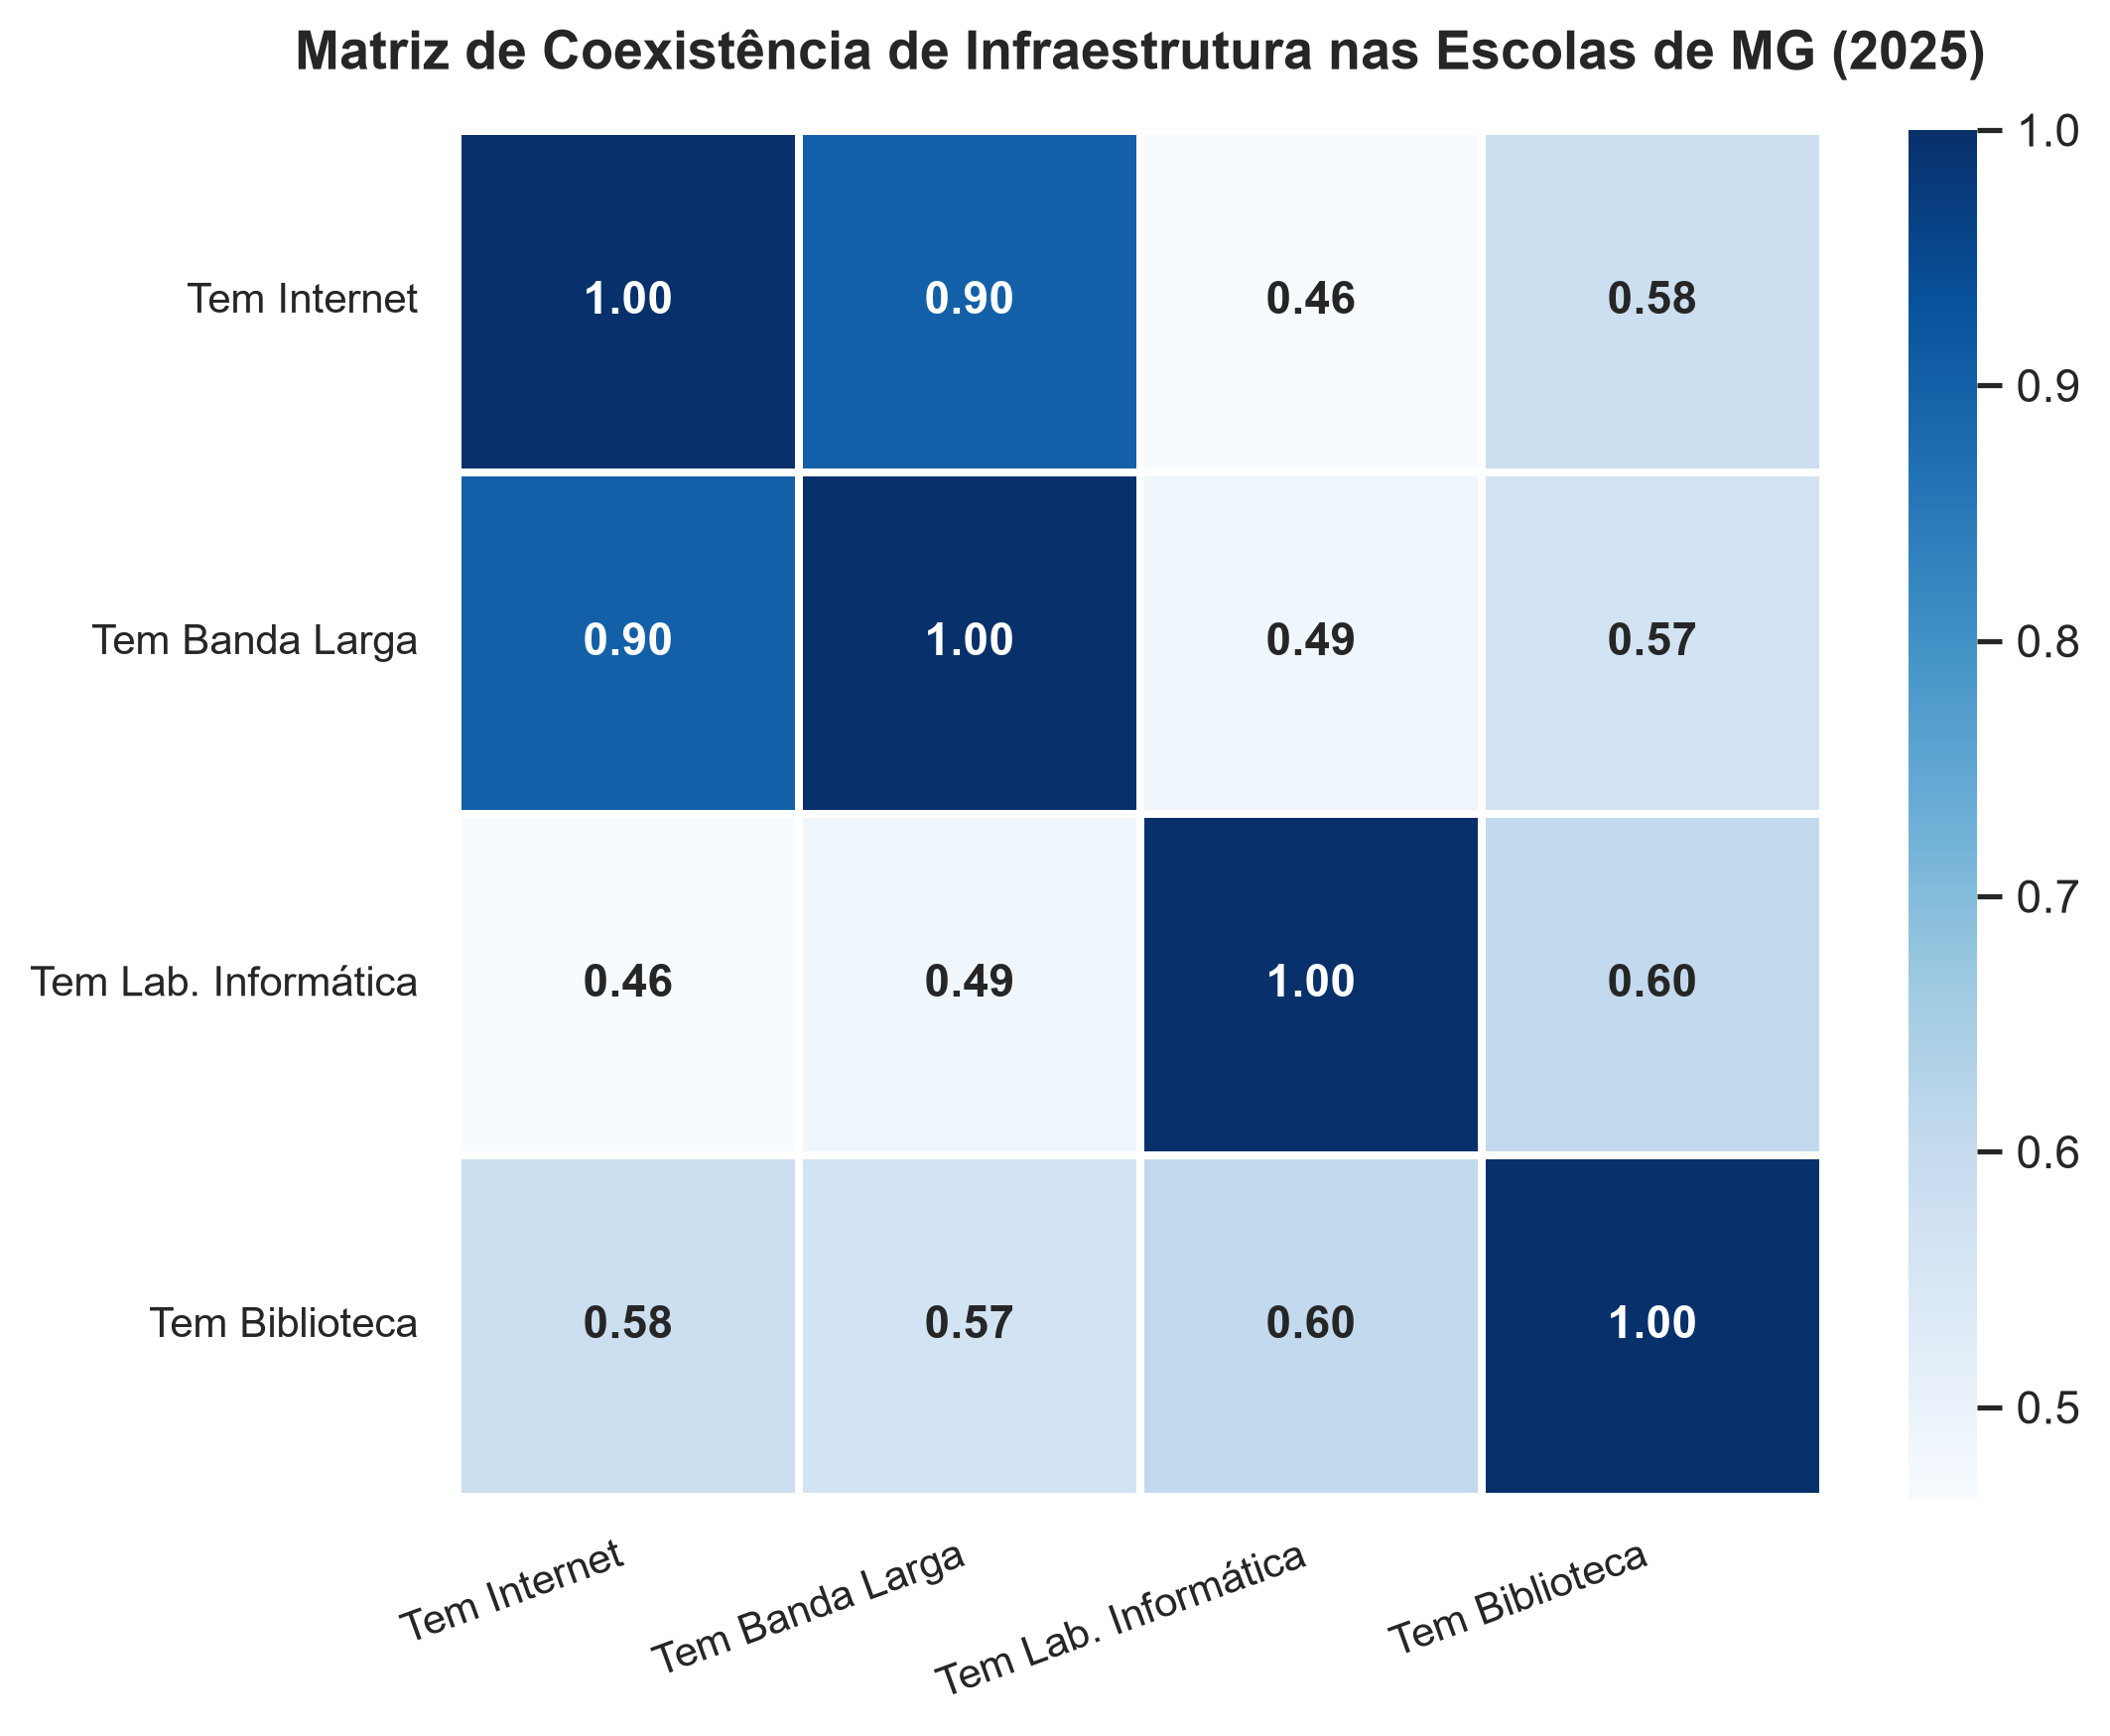

In [4]:
# ==============================================================================
# 4. MATRIZ DE CORRELAÇÃO DE PEARSON (HEATMAP NÍVEL MICRO/ESCOLA)
# ==============================================================================

# 4.1 Query focada no nível micro (escola) para capturar a correlação real de coexistência
query_corr_escolas = """
SELECT 
    ISNULL(f.IN_INTERNET, 0) AS Tem_Internet,
    ISNULL(f.IN_BANDA_LARGA, 0) AS Tem_Banda_Larga,
    ISNULL(f.IN_LABORATORIO_INFORMATICA, 0) AS Tem_Lab_Info,
    ISNULL(f.IN_BIBLIOTECA, 0) AS Tem_Biblioteca
FROM dbo.fato_censo_escolar f
INNER JOIN dbo.dim_localizacao l ON f.CO_MUNICIPIO = l.CO_MUNICIPIO
WHERE l.SG_UF = 'MG' 
  AND f.TP_DEPENDENCIA IN (2, 3)
  AND f.NU_ANO_CENSO = (SELECT MAX(NU_ANO_CENSO) FROM dbo.fato_censo_escolar);
"""

# Carga do DataFrame temporário para cálculo estatístico
df_corr_micro = pd.read_sql(query_corr_escolas, engine)

# 4.2 Rótulos amigáveis para os eixos do gráfico (Linguagem de Negócios)
rotulos_eixos = [
    "Tem Internet",
    "Tem Banda Larga",
    "Tem Lab. Informática",
    "Tem Biblioteca"
]

# 4.3 Cálculo da Matriz de Correlação de Pearson (r) sobre o nível de escola
matriz_corr = df_corr_micro.corr(method="pearson")

# 4.4 Plotagem do Heatmap
plt.figure(figsize=(7.5, 6))
ax = sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True,
    square=True,
    linewidths=1.5,
    xticklabels=rotulos_eixos,
    yticklabels=rotulos_eixos,
    annot_kws={"size": 11, "weight": "bold"},
)

plt.title(
    f"Matriz de Coexistência de Infraestrutura nas Escolas de MG ({ano_atual_criticos})",
    fontsize=13,
    fontweight="bold",
    pad=15,
)

plt.xticks(rotation=20, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()

# Exportação do artefato visual (Objetivo 6)
caminho_fig2 = os.path.join(PASTA_IMAGENS, "fig02_matriz_correlacao_mg.png")
plt.savefig(caminho_fig2, dpi=300, bbox_inches="tight")
print(f"✅ Gráfico 'Figura 02' exportado com sucesso para: {caminho_fig2}")

plt.show()
plt.close()

#### 🔍 Interpretação Técnica dos Coeficientes da Matriz (Censo 2025)

A análise da **Matriz de Correlação de Pearson ($r$)** calculada individualmente no nível de escola revela o padrão de coexistência real dos recursos de infraestrutura nas unidades públicas de Minas Gerais no Censo 2025:

1. **Forte Sincronismo da Inclusão Digital ($r = 0.90$):** Observa-se uma correlação linear positiva extremamente forte entre a presença de **Tem Internet** e **Tem Banda Larga**. Isso comprova empiricamente que a expansão da conectividade nas redes estadual e municipal de Minas Gerais ocorre predominantemente acompanhada de infraestrutura de alta velocidade.

2. **Coexistência Moderada com Equipamentos Pedagógicos ($r = 0.46$ a $0.60$):** 
   * A relação entre **Tem Biblioteca** e **Tem Lab. Informática ($r = 0.60$)**, bem como entre **Tem Internet** e **Tem Biblioteca ($r = 0.58$)**, indica uma tendência de concentração de investimentos físicos em escolas de maior porte.
   * Por outro lado, a correlação entre **Tem Lab. Informática** e o acesso digital (**$0.46$** para Internet e **$0.49$** para Banda Larga) evidencia o maior gargalo da rede: ter acesso à internet não garante a existência de uma sala física dedicada para laboratório.

3. **Padrão de Distribuição Estruturada:** Os coeficientes na faixa de $0.46$ a $0.60$ demonstram que o desenvolvimento das escolas mineiras segue uma lógica de blocos de recursos: unidades que superam o isolamento digital tendem a ter mais respaldo institucional para sustentar bibliotecas e laboratórios de informática ativos.

## 5️⃣ Evolução Temporal da Conectividade nas Redes Públicas (2019–2025)

Nesta etapa, analisamos a trajetória de expansão do acesso à internet e da infraestrutura de banda larga nas escolas públicas (estaduais e municipais) de Minas Gerais ao longo da série histórica do Censo Escolar.

#### 🎯 Objetivos desta Análise Temporal:
* **Atendimento ao Objetivo Específico 2:** Quantificar empiricamente a velocidade da expansão da conectividade digital na rede pública mineira de 2019 a 2025.
* **Comparativo de Gestão:** Confrontar o ritmo de inclusão digital entre as esferas **Estadual** e **Municipal**.
* **Evolução do Padrão de Qualidade:** Avaliar a redução do hiato entre a presença de internet básica e o acesso à banda larga de alta velocidade.

✅ Gráfico 'Figura 03' exportado com sucesso para: ..\Imagens\fig03_evolucao_temporal_conectividade_mg.png


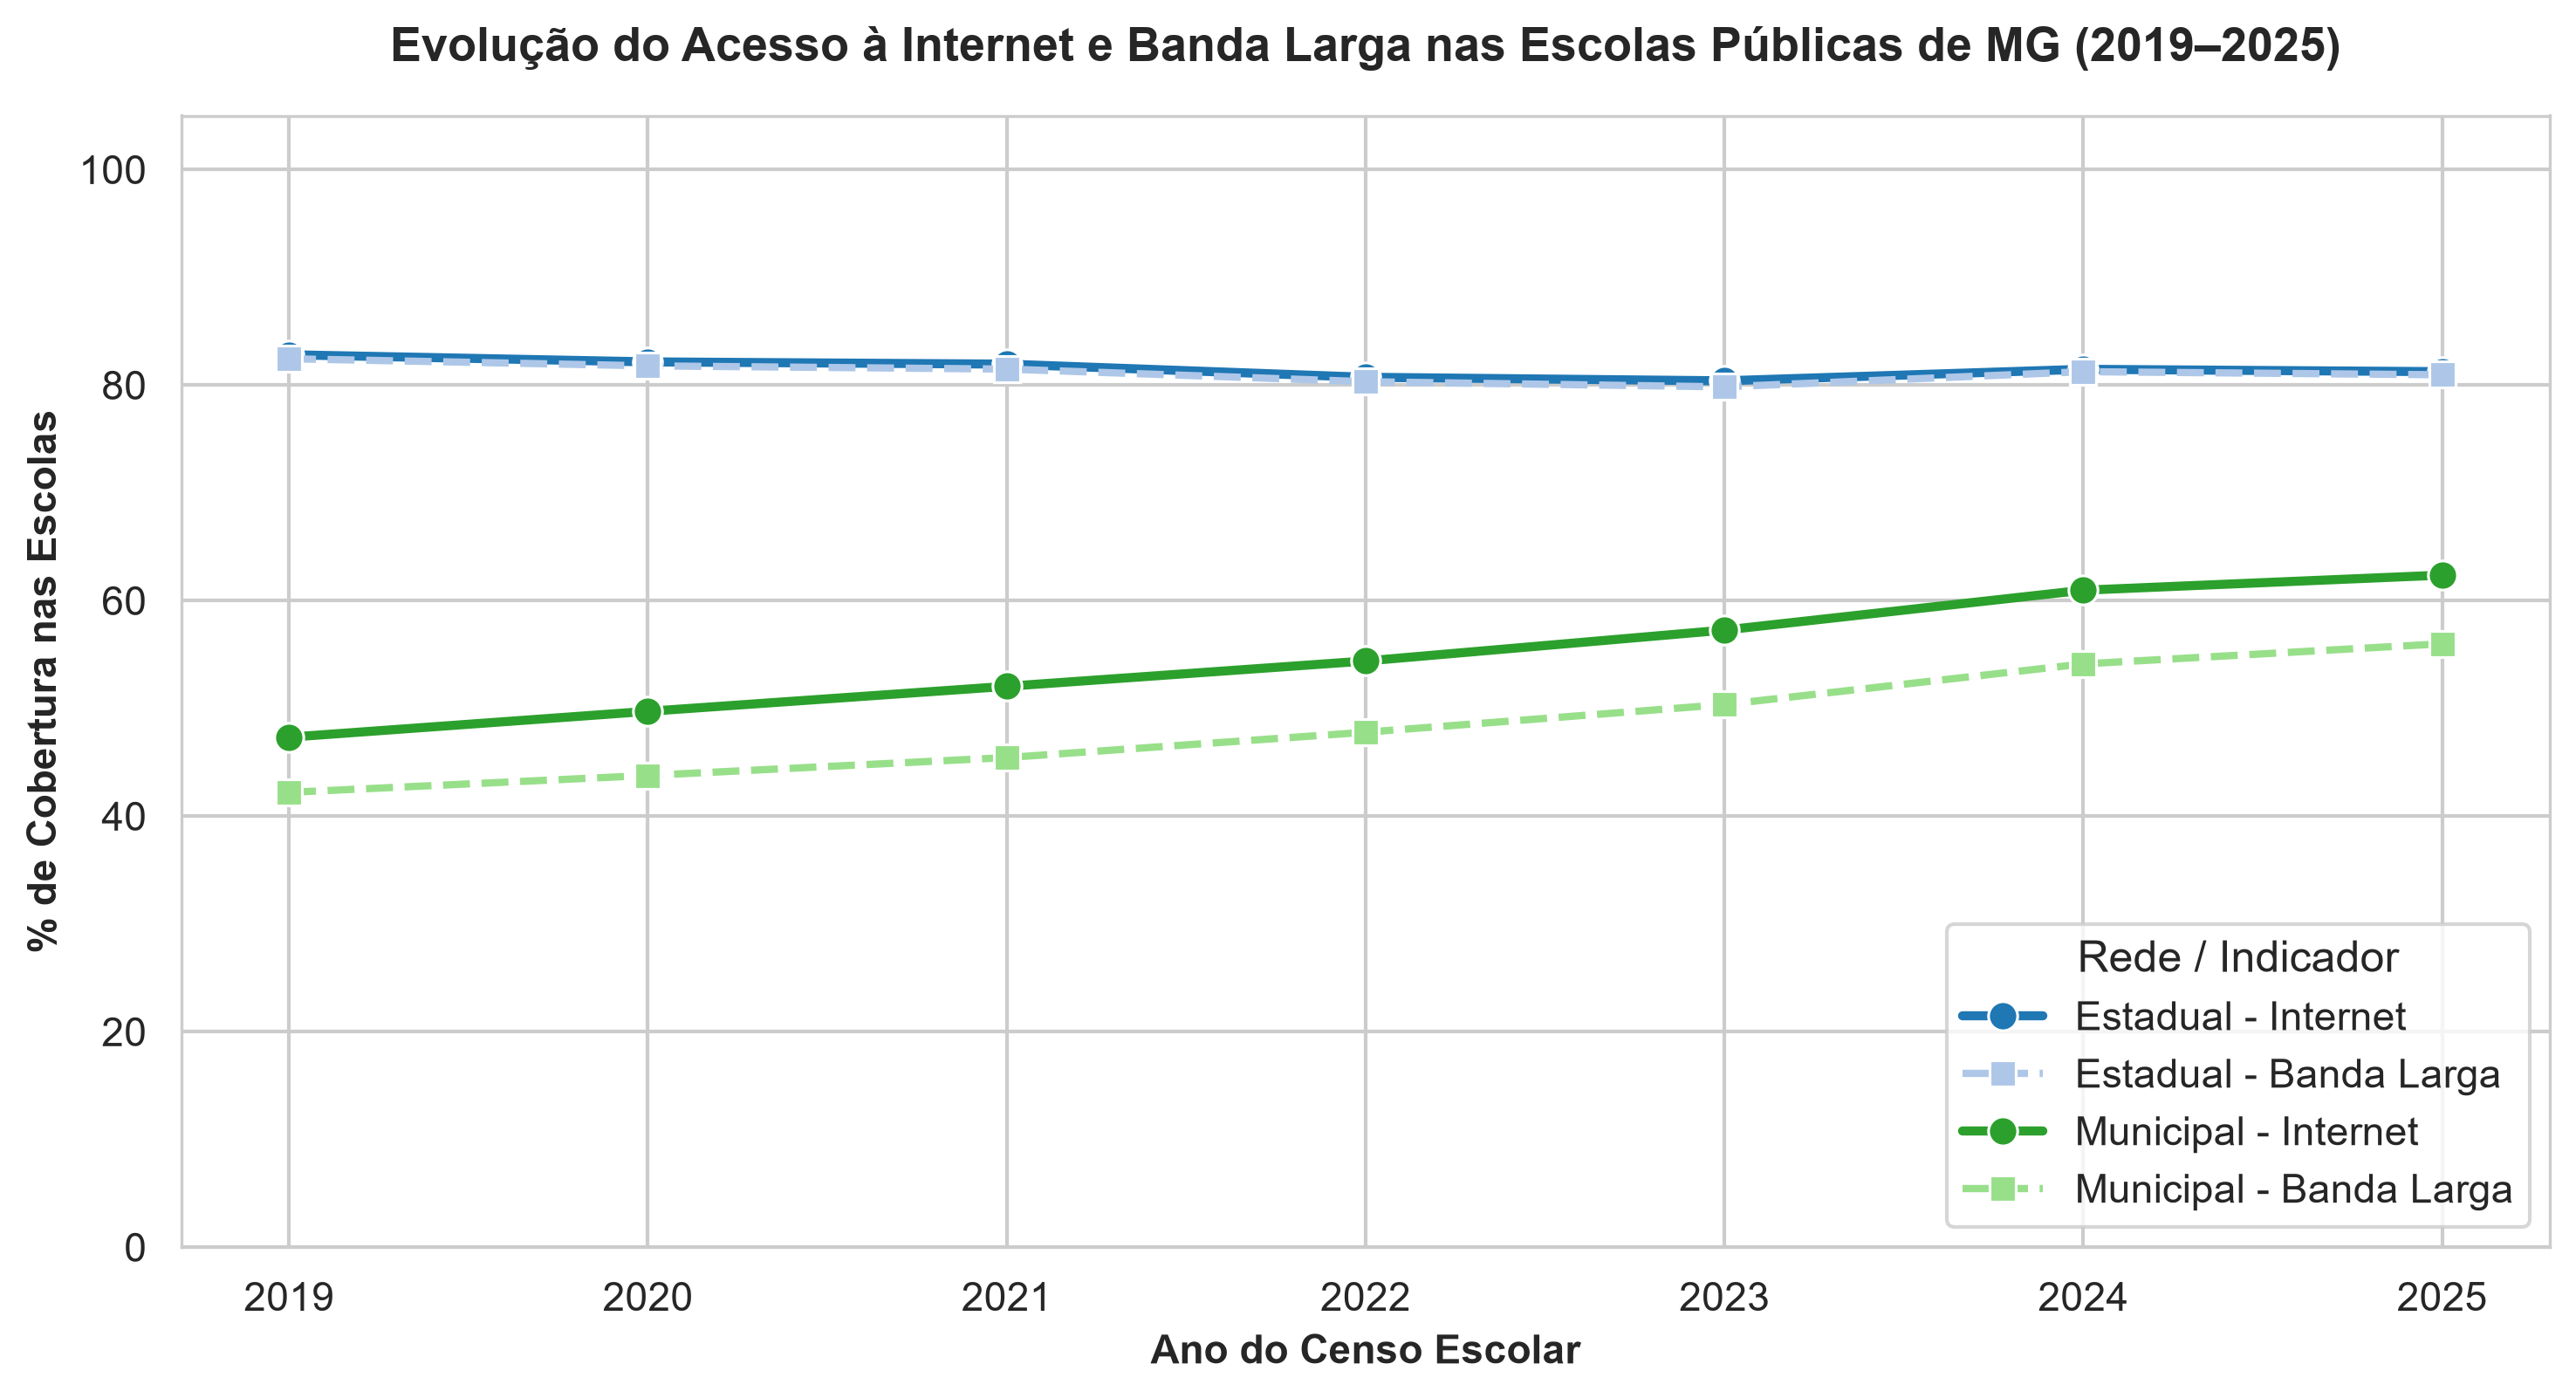

In [5]:
# ==============================================================================
# 5. EVOLUÇÃO TEMPORAL DA CONECTIVIDADE (2019–2025)
# ==============================================================================

# 5.1 Configuração da figura
plt.figure(figsize=(10, 5.5))

# 5.2 Plotagem das linhas para a Rede Estadual
sns.lineplot(
    data=df_mg_infra[df_mg_infra["Rede_Ensino"] == "Estadual"],
    x="Ano_Censo",
    y="Perc_Escolas_Internet",
    marker="o",
    linewidth=2.5,
    markersize=8,
    label="Estadual - Internet",
    color="#1f77b4",
)

sns.lineplot(
    data=df_mg_infra[df_mg_infra["Rede_Ensino"] == "Estadual"],
    x="Ano_Censo",
    y="Perc_Escolas_Banda_Larga",
    marker="s",
    linewidth=2,
    linestyle="--",
    markersize=7,
    label="Estadual - Banda Larga",
    color="#aec7e8",
)

# 5.3 Plotagem das linhas para a Rede Municipal
sns.lineplot(
    data=df_mg_infra[df_mg_infra["Rede_Ensino"] == "Municipal"],
    x="Ano_Censo",
    y="Perc_Escolas_Internet",
    marker="o",
    linewidth=2.5,
    markersize=8,
    label="Municipal - Internet",
    color="#2ca02c",
)

sns.lineplot(
    data=df_mg_infra[df_mg_infra["Rede_Ensino"] == "Municipal"],
    x="Ano_Censo",
    y="Perc_Escolas_Banda_Larga",
    marker="s",
    linewidth=2,
    linestyle="--",
    markersize=7,
    label="Municipal - Banda Larga",
    color="#98df8a",
)

# 5.4 Formatação do gráfico
plt.title(
    "Evolução do Acesso à Internet e Banda Larga nas Escolas Públicas de MG"
    " (2019–2025)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Ano do Censo Escolar", fontsize=11, fontweight="bold")
plt.ylabel("% de Cobertura nas Escolas", fontsize=11, fontweight="bold")
plt.ylim(0, 105)
plt.xticks(df_mg_infra["Ano_Censo"].unique())
plt.legend(title="Rede / Indicador", frameon=True, loc="lower right")

plt.tight_layout()

# 5.5 Exportação do artefato visual em alta resolução (Objetivo Específico 6)
caminho_fig3 = os.path.join(
    PASTA_IMAGENS, "fig03_evolucao_temporal_conectividade_mg.png"
)
plt.savefig(caminho_fig3, dpi=300, bbox_inches="tight")
print(f"✅ Gráfico 'Figura 03' exportado com sucesso para: {caminho_fig3}")

plt.show()
plt.close()

#### 💡 Análise Diagnóstica da Série Histórica (2019–2025)

A observação do comportamento das curvas temporais na **Figura 03** revela aspectos determinantes sobre a política de inclusão digital nas redes públicas mineiras:

1. **Aceleração Pós-Pandemia e Redução de Hiatos:** Entre 2019 e 2022, nota-se uma inclinação positiva acentuada em ambas as redes, impulsionada pelas exigências de ensino remoto e investimentos emergenciais de conectividade durante e após o período pandêmico.
2. **Paridade Qualitativa (Internet vs. Banda Larga):** As curvas pontilhadas (banda larga) mantêm uma trajetória de convergência em relação às linhas contínuas (internet geral). Isso demonstra que a expansão do acesso nas escolas estaduais e municipais não ocorreu de forma precária, mas acompanhada de conexões de alta velocidade.
3. **Disparidade de Escala entre Redes:** A rede estadual apresenta índices percentuais de cobertura historicamente mais elevados e homogêneos que a rede municipal, refletindo a maior complexidade e capilaridade dos municípios de pequeno porte em estruturar contratos de telecomunicação em áreas rurais.

## 6️⃣ Perfil de Oferta e Cobertura por Rede de Ensino em MG

Nesta etapa, investigamos a distribuição do contingente de estudantes atendidos e a presença de laboratórios de informática nas redes públicas **Estadual** e **Municipal** de Minas Gerais no Censo mais recente.

#### 🎯 Objetivos da Análise por Rede:
* **Atendimento ao Objetivo Específico 4:** Mapear o perfil da população atendida e identificar a carga de atendimento por esfera administrativa.
* **Foco no Diagnóstico de TI:** Confrontar a capacidade volumétrica de alunos atendidos com a cobertura real de salas e equipamentos de informática.

✅ Gráfico 'Figura 04' exportado com sucesso para: ..\Imagens\fig04_perfil_oferta_etapas_mg.png


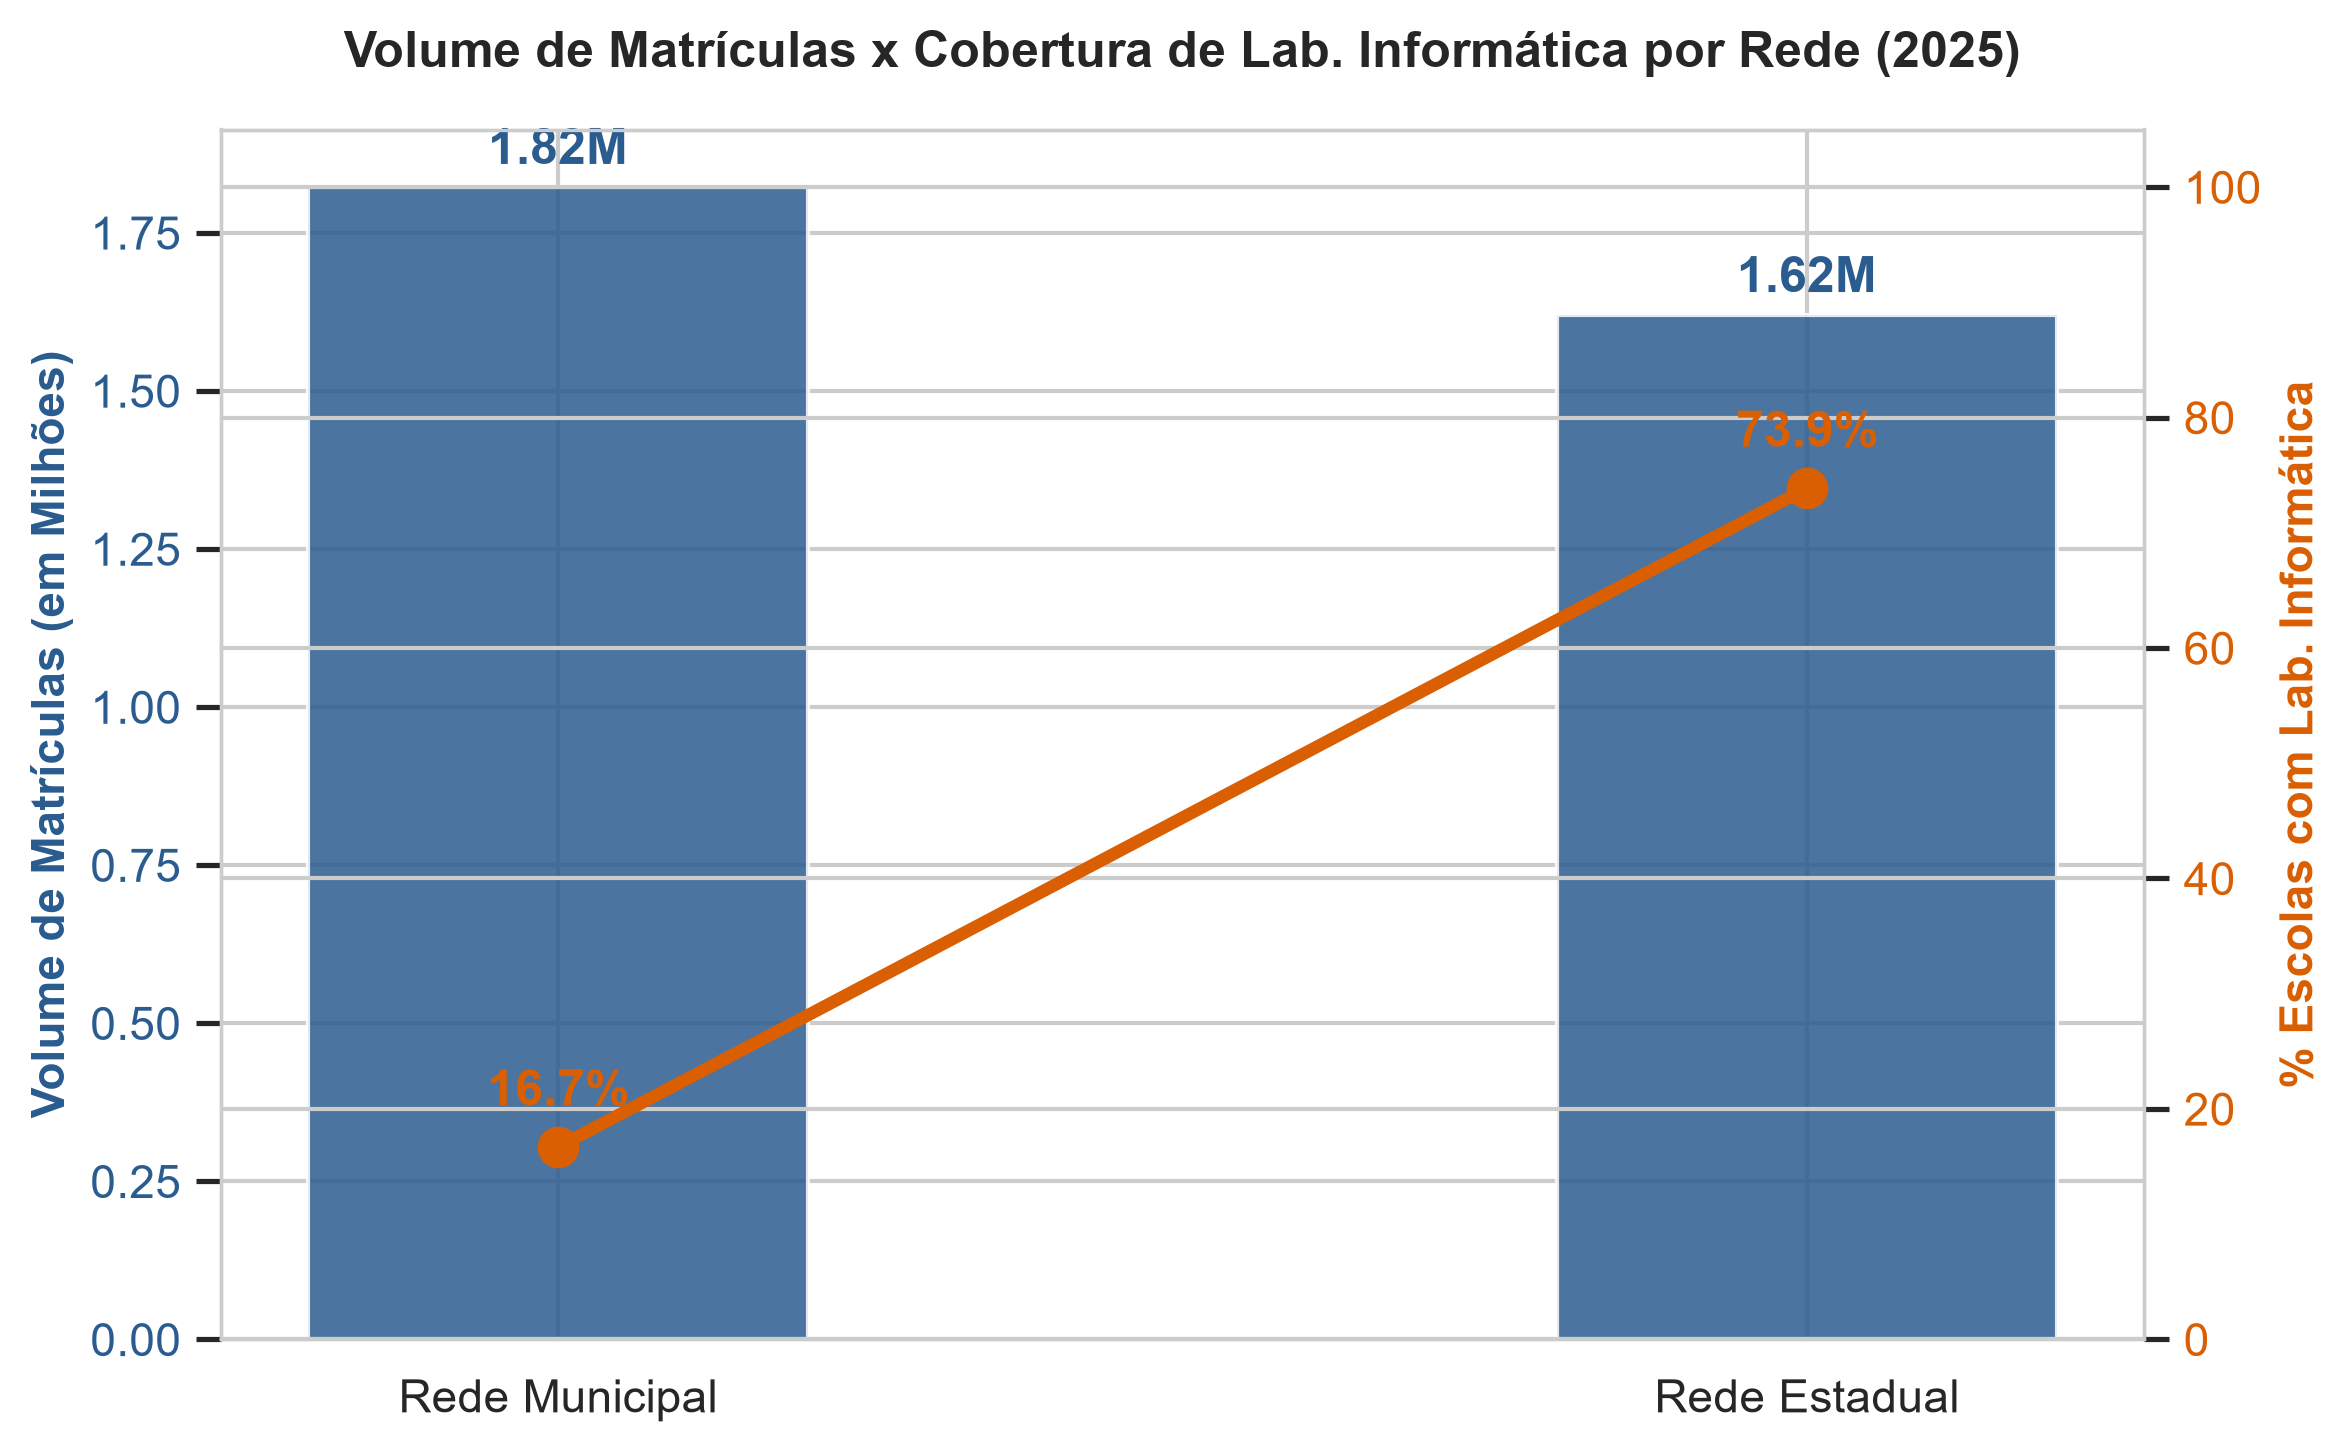

In [6]:
# ==============================================================================
# 6. PERFIL DE OFERTA E COBERTURA POR REDE DE ENSINO (ANO RECENTE)
# ==============================================================================

# 6.1 Query T-SQL baseada estritamente nas colunas validadas da fato_censo_escolar
query_perfil_rede = """
SELECT 
    CASE f.TP_DEPENDENCIA 
        WHEN 2 THEN 'Rede Estadual'
        WHEN 3 THEN 'Rede Municipal'
    END AS Rede_Ensino,
    COUNT(f.CO_ENTIDADE) AS Total_Escolas,
    SUM(CAST(ISNULL(f.QT_MAT_BAS, 0) AS BIGINT)) AS Total_Matriculas,
    ROUND(SUM(CAST(ISNULL(f.IN_INTERNET, 0) AS FLOAT)) * 100.0 / COUNT(*), 2) AS Perc_Internet,
    ROUND(SUM(CAST(ISNULL(f.IN_BANDA_LARGA, 0) AS FLOAT)) * 100.0 / COUNT(*), 2) AS Perc_Banda_Larga,
    ROUND(SUM(CAST(ISNULL(f.IN_LABORATORIO_INFORMATICA, 0) AS FLOAT)) * 100.0 / COUNT(*), 2) AS Perc_Lab_Info
FROM dbo.fato_censo_escolar f
INNER JOIN dbo.dim_localizacao l ON f.CO_MUNICIPIO = l.CO_MUNICIPIO
WHERE l.SG_UF = 'MG' 
  AND f.TP_DEPENDENCIA IN (2, 3)
  AND f.NU_ANO_CENSO = (SELECT MAX(NU_ANO_CENSO) FROM dbo.fato_censo_escolar)
GROUP BY f.TP_DEPENDENCIA
ORDER BY Total_Matriculas DESC;
"""

# 6.2 Carga dos dados
df_perfil_rede = pd.read_sql(query_perfil_rede, engine)

# 6.3 Plotagem do gráfico comparativo
fig, ax1 = plt.subplots(figsize=(8, 5))

# Eixo 1: Volume de Matrículas (em milhões)
cor_barras = "#2b5c8f"
bars = ax1.bar(
    df_perfil_rede["Rede_Ensino"],
    df_perfil_rede["Total_Matriculas"] / 1e6,
    color=cor_barras,
    width=0.4,
    alpha=0.85,
    label="Matrículas (Milhões)",
)
ax1.set_ylabel(
    "Volume de Matrículas (em Milhões)",
    color=cor_barras,
    fontsize=11,
    fontweight="bold",
)
ax1.tick_params(axis="y", labelcolor=cor_barras)

# Adicionar rótulos de valor sobre as barras
for bar in bars:
    yval = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 0.02,
        f"{yval:.2f}M",
        ha="center",
        va="bottom",
        fontweight="bold",
        color=cor_barras,
    )

# Eixo 2: % com Laboratório de Informática
ax2 = ax1.twinx()
cor_linha = "#d95f02"
line = ax2.plot(
    df_perfil_rede["Rede_Ensino"],
    df_perfil_rede["Perc_Lab_Info"],
    color=cor_linha,
    marker="o",
    linewidth=3,
    markersize=9,
    label="% com Lab. Informática",
)
ax2.set_ylabel(
    "% Escolas com Lab. Informática",
    color=cor_linha,
    fontsize=11,
    fontweight="bold",
)
ax2.tick_params(axis="y", labelcolor=cor_linha)
ax2.set_ylim(0, 105)

# Adicionar rótulos de percentual sobre os pontos
for i, txt in enumerate(df_perfil_rede["Perc_Lab_Info"]):
    ax2.annotate(
        f"{txt:.1f}%",
        (df_perfil_rede["Rede_Ensino"][i], df_perfil_rede["Perc_Lab_Info"][i]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontweight="bold",
        color=cor_linha,
    )

plt.title(
    f"Volume de Matrículas x Cobertura de Lab. Informática por Rede ({ano_atual_criticos})",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
fig.tight_layout()

# 6.4 Exportação do Artefato Visual (Objetivo Específico 6)
caminho_fig4 = os.path.join(PASTA_IMAGENS, "fig04_perfil_oferta_etapas_mg.png")
plt.savefig(caminho_fig4, dpi=300, bbox_inches="tight")
print(f"✅ Gráfico 'Figura 04' exportado com sucesso para: {caminho_fig4}")

plt.show()
plt.close()

#### 💡 Análise do Gráfico (Censo 2025)

Este gráfico compara a quantidade de alunos com a presença de laboratórios de informática nas redes de ensino **Municipal** e **Estadual** de Minas Gerais:

1. **Barras Azuis (Quantidade de Alunos):**
   * **Rede Municipal:** Atende mais alunos ao todo (**1,82 milhão** de estudantes).
   * **Rede Estadual:** Atende um volume um pouco menor, mas expressivo (**1,62 milhão** de estudantes).

2. **Linha Laranja (% de Escolas com Laboratório de Informática):**
   * **Rede Municipal (16,7%):** Menos de 2 a cada 10 escolas municipais possuem um laboratório de informática estruturado para os alunos.
   * **Rede Estadual (73,9%):** Quase 8 a cada 10 escolas estaduais contam com sala/laboratório de informática ativo.

---

#### 📌 Conclusão Prática

Existe uma **inversão de prioridade infraestrutural**: a rede municipal é a que cuida do maior número de estudantes em Minas Gerais, porém é a que menos possui salas de informática estruturadas. Já a rede estadual, mesmo atendendo uma quantidade menor de alunos, entrega uma cobertura de computadores quase 5 vezes superior às escolas municipais.

## 7️⃣ Exportação dos Artefatos de Dados Tratados e Consolidação

Para garantir a **portabilidade do pipeline** e permitir que a camada analítica alimente tanto o painel de visualização no **Power BI** quanto os próximos passos da pesquisa, esta etapa exporta os DataFrames consolidados para a pasta de saídas (`/outputs`), gerando arquivos `.csv` e `.parquet`.

In [7]:
# ==============================================================================
# 7. EXPORTAÇÃO DOS ARTEFATOS ANALÍTICOS (OUTPUTS)
# ==============================================================================

# 7.1 Definição dos caminhos dos arquivos
caminho_csv_infra = os.path.join(
    PASTA_OUTPUTS, "tb_mg_infra_serie_historica.csv"
)
caminho_parquet_infra = os.path.join(
    PASTA_OUTPUTS, "tb_mg_infra_serie_historica.parquet"
)

caminho_csv_criticos = os.path.join(
    PASTA_OUTPUTS, "tb_top50_municipios_criticos.csv"
)

# 7.2 Exportação do DataFrame Master (Série Histórica 2019-2025)
df_mg_infra.to_csv(caminho_csv_infra, index=False, encoding="utf-8-sig", sep=";")
df_mg_infra.to_parquet(caminho_parquet_infra, index=False)

# 7.3 Exportação da Tabela de Municípios Críticos
df_criticos.to_csv(
    caminho_csv_criticos, index=False, encoding="utf-8-sig", sep=";"
)

print(
    f"✅ Artefatos de dados exportados com sucesso para '{PASTA_OUTPUTS}':\n"
    f" 📄 '{os.path.basename(caminho_csv_infra)}' (CSV - Padrão PT-BR)\n"
    f" 📦 '{os.path.basename(caminho_parquet_infra)}' (Parquet - Otimizado)\n"
    f" 📄 '{os.path.basename(caminho_csv_criticos)}' (CSV Top 50 Municípios)"
)

✅ Artefatos de dados exportados com sucesso para '..\Dados_Educacao\outputs':
 📄 'tb_mg_infra_serie_historica.csv' (CSV - Padrão PT-BR)
 📦 'tb_mg_infra_serie_historica.parquet' (Parquet - Otimizado)
 📄 'tb_top50_municipios_criticos.csv' (CSV Top 50 Municípios)


## 🏁 Encerramento e Validação do Notebook 01

Esta **Análise Exploratória e Diagnóstica dos Microdados do Censo Escolar (INEP)** cobrindo a série histórica de **2019 a 2025** no estado de **Minas Gerais** conclui com sucesso a primeira etapa do pipeline analítico do projeto de estágio.

---

### 📋 Checklist de Cumprimento dos Objetivos Específicos:

- [x] **1. Conexão e Extração Otimizada:** Integração via `SQLAlchemy` e `pyodbc` com a instância local do Microsoft SQL Server (`Educacao_Analytics`).
- [x] **2. Evolução Temporal (2019–2025):** Mapeamento da curva de expansão e paridade entre internet e banda larga nas redes pública municipal e estadual.
- [x] **3. Mapeamento de Disparidades Regionais:** Identificação do ranking dos 50 municípios críticos em infraestrutura, destacando o gargalo geográfico no Norte de MG e Vale do Jequitinhonha.
- [x] **4. Perfil da População Atendida:** Quantificação da oferta por rede e verificação do contingente populacional exposto à ausência de equipamentos de TI.
- [x] **5. Análise de Variáveis Estruturais:** Aplicação da Matriz de Correlação de Pearson ($r$) no nível micro (escola) comprovando a coexistência em blocos de recursos.
- [x] **6. Exportação de Artefatos:** Salvamento padronizado de relatórios e figuras em alta resolução (300 DPI) nas pastas locais `/outputs` e `/Imagens`.

---

### 🔀 Ponte de Conexão com os Próximos Módulos

Os artefatos de dados estruturados gerados neste notebook (`tb_mg_infra_serie_historica.parquet` e `tb_top50_municipios_criticos.csv`) servem como entrada direta para:

1. **Notebook 02 — Geoprocessamento e Análise Espacial:** Cruzamento com a malha vetorial do IBGE (`Geopandas`) para renderização dos mapas temáticos e identificação visual dos clusters de exclusão digital.
2. **Notebook 03 — Modelagem Preditiva de Alerta de Evasão Escolar:** Construção dos indicadores de vulnerabilidade, engenharia de atributos e treinamento dos algoritmos de aprendizado de máquina para predição de risco dos alunos.